In [1]:
# For tips on running notebooks in Google Colab, see
# https://docs.pytorch.org/tutorials/beginner/colab
%matplotlib inline

Tensors
=======

Tensors are a specialized data structure that are very similar to arrays
and matrices. In PyTorch, we use tensors to encode the inputs and
outputs of a model, as well as the model's parameters.

Tensors are similar to NumPy's ndarrays, except that tensors can run on
GPUs or other specialized hardware to accelerate computing. If you're
familiar with ndarrays, you'll be right at home with the Tensor API. If
not, follow along in this quick API walkthrough.


In [2]:
import torch
import numpy as np

Tensor Initialization
=====================

Tensors can be initialized in various ways. Take a look at the following
examples:

**Directly from data**

Tensors can be created directly from data. The data type is
automatically inferred.


In [3]:
data = [[1, 2, 3], [4, 5, 6]]
x_data = torch.tensor(data)

**From a NumPy array**

Tensors can be created from NumPy arrays (and vice versa - see
`bridge-to-np-label`{.interpreted-text role="ref"}).


In [4]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)

**From another tensor:**

The new tensor retains the properties (shape, datatype) of the argument
tensor, unless explicitly overridden.


In [5]:
x_ones = torch.ones_like(x_data) # retains the properties of x_data
print(f"Ones Tensor: \n {x_ones} \n")

x_rand = torch.rand_like(x_data, dtype=torch.float) # overrides the datatype of x_data
print(f"Random Tensor: \n {x_rand} \n")

Ones Tensor: 
 tensor([[1, 1, 1],
        [1, 1, 1]]) 

Random Tensor: 
 tensor([[0.9502, 0.2843, 0.0947],
        [0.2882, 0.8580, 0.0388]]) 



**With random or constant values:**

`shape` is a tuple of tensor dimensions. In the functions below, it
determines the dimensionality of the output tensor.


In [6]:
shape = (2, 3,)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor}")

Random Tensor: 
 tensor([[0.1463, 0.2891, 0.1103],
        [0.6137, 0.0328, 0.3075]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]])


------------------------------------------------------------------------


Tensor Attributes
=================

Tensor attributes describe their shape, datatype, and the device on
which they are stored.


In [7]:
tensor = torch.rand(3, 4)

print(f"Shape of tensor: {tensor.shape}")
print(f"Datatype of tensor: {tensor.dtype}")
print(f"Device tensor is stored on: {tensor.device}")

Shape of tensor: torch.Size([3, 4])
Datatype of tensor: torch.float32
Device tensor is stored on: cpu


------------------------------------------------------------------------


Tensor Operations
=================

Over 100 tensor operations, including transposing, indexing, slicing,
mathematical operations, linear algebra, random sampling, and more are
comprehensively described
[here](https://pytorch.org/docs/stable/torch.html).

Each of them can be run on the GPU (at typically higher speeds than on a
CPU). If you're using Colab, allocate a GPU by going to Edit \> Notebook
Settings.


In [8]:
# We move our tensor to the GPU if available
if torch.cuda.is_available():
  tensor = tensor.to('cuda')
  print(f"Device tensor is stored on: {tensor.device}")

Try out some of the operations from the list. If you\'re familiar with
the NumPy API, you\'ll find the Tensor API a breeze to use.


**Standard numpy-like indexing and slicing:**


In [9]:
tensor = torch.ones(4, 4)
tensor[:,1] = 0
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


**Joining tensors** You can use `torch.cat` to concatenate a sequence of
tensors along a given dimension. See also
[torch.stack](https://pytorch.org/docs/stable/generated/torch.stack.html),
another tensor joining op that is subtly different from `torch.cat`.


In [10]:
t1 = torch.cat([tensor, tensor, tensor], dim=1)
print(t1)

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])


**Multiplying tensors**


In [11]:
# This computes the element-wise product
print(f"tensor.mul(tensor) \n {tensor.mul(tensor)} \n")
# Alternative syntax:
print(f"tensor * tensor \n {tensor * tensor}")

tensor.mul(tensor) 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor * tensor 
 tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])


This computes the matrix multiplication between two tensors


In [12]:
print(f"tensor.matmul(tensor.T) \n {tensor.matmul(tensor.T)} \n")
# Alternative syntax:
print(f"tensor @ tensor.T \n {tensor @ tensor.T}")

tensor.matmul(tensor.T) 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]]) 

tensor @ tensor.T 
 tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])


**In-place operations** Operations that have a `_` suffix are in-place.
For example: `x.copy_(y)`, `x.t_()`, will change `x`.


In [13]:
print(tensor, "\n")
tensor.add_(5)
print(tensor)

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]])


<div style="background-color: #54c7ec; color: #fff; font-weight: 700; padding-left: 10px; padding-top: 5px; padding-bottom: 5px"><strong>NOTE:</strong></div>

<div style="background-color: #f3f4f7; padding-left: 10px; padding-top: 10px; padding-bottom: 10px; padding-right: 10px">

<p>In-place operations save some memory, but can be problematic when computing derivatives because of an immediate lossof history. Hence, their use is discouraged.</p>

</div>



------------------------------------------------------------------------


Bridge with NumPy {#bridge-to-np-label}
=================

Tensors on the CPU and NumPy arrays can share their underlying memory
locations, and changing one will change the other.


Tensor to NumPy array
=====================


In [14]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


A change in the tensor reflects in the NumPy array.


In [15]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


NumPy array to Tensor
=====================


In [16]:
n = np.ones(5)
t = torch.from_numpy(n)

Changes in the NumPy array reflects in the tensor.


In [17]:
np.add(n, 1, out=n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


# Section 2: Intro to Autograd

In [18]:
import torch
from torchvision.models import resnet18, ResNet18_Weights
model = resnet18(weights=ResNet18_Weights.DEFAULT)
data = torch.rand(1, 3, 64, 64) # [batch_size, channels, height, width]
labels = torch.rand(1, 1000)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 137MB/s]


In [19]:
print(data)
print(data.shape)

tensor([[[[0.0501, 0.4600, 0.1395,  ..., 0.6564, 0.0390, 0.1431],
          [0.5203, 0.7135, 0.9904,  ..., 0.0677, 0.1430, 0.8776],
          [0.3688, 0.0756, 0.5285,  ..., 0.8736, 0.7037, 0.0547],
          ...,
          [0.1503, 0.1691, 0.3106,  ..., 0.5302, 0.2470, 0.4198],
          [0.0505, 0.4606, 0.1533,  ..., 0.2171, 0.7380, 0.9146],
          [0.0337, 0.1627, 0.2620,  ..., 0.2269, 0.3059, 0.4271]],

         [[0.5873, 0.1124, 0.1125,  ..., 0.5516, 0.6492, 0.5446],
          [0.1786, 0.3881, 0.3555,  ..., 0.2049, 0.7809, 0.4276],
          [0.6370, 0.1609, 0.2143,  ..., 0.8959, 0.4251, 0.8261],
          ...,
          [0.8793, 0.0013, 0.0693,  ..., 0.5832, 0.5328, 0.7382],
          [0.2938, 0.1710, 0.1871,  ..., 0.9081, 0.0113, 0.3544],
          [0.1253, 0.7963, 0.2259,  ..., 0.5567, 0.5445, 0.6286]],

         [[0.9682, 0.9455, 0.6552,  ..., 0.0577, 0.4431, 0.2019],
          [0.3726, 0.6572, 0.4009,  ..., 0.5150, 0.9108, 0.9635],
          [0.8209, 0.9632, 0.5225,  ..., 0

In [20]:
prediction = model(data)

In [21]:
loss = (prediction - labels).sum()
loss.backward() # backward pass

In [22]:
# print(model.parameters())

In [23]:
optim = torch.optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

In [24]:
optim.step()

In [25]:
import torch

a = torch.tensor([3., 2.], requires_grad=True)
b = torch.tensor([4., 6.], requires_grad=True)

In [26]:
Q = 4*a**3 - b**2

In [27]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)

In [28]:
# check if collected gradients are correct
print(12*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])


In [29]:
x = torch.rand(5, 5)
y = torch.rand(5, 5)
z = torch.rand((5, 5), requires_grad=True)

a = x + y
print(f"Does `a` require gradients?: {a.requires_grad}")
b = x + z
print(f"Does `b` require gradients?: {b.requires_grad}")

Does `a` require gradients?: False
Does `b` require gradients?: True


In [30]:
from torch import nn, optim

model = resnet18(weights=ResNet18_Weights.DEFAULT)
# print(len(model.parameters()))
# Freeze all the parameters in the network
for param in model.parameters():
    param.requires_grad = False

In [31]:
model.fc = nn.Linear(512, 10)

In [32]:
# Optimize only the classifier
optimizer = optim.SGD(model.parameters(), lr=1e-2, momentum=0.9)

# Section3: Neural Network

In [33]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):

    def __init__(self):
        super(Net, self).__init__()
        # 1 input image channel, 6 output channels, 5x5 square convolution
        # kernel
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.conv2 = nn.Conv2d(6, 16, 5)
        # an affine operation: y = Wx + b
        self.fc1 = nn.Linear(16 * 5 * 5, 120)  # 5*5 from image dimension
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, input):
        # Convolution layer C1: 1 input image channel, 6 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a Tensor with size (N, 6, 28, 28), where N is the size of the batch
        c1 = F.relu(self.conv1(input))
        # Subsampling layer S2: 2x2 grid, purely functional,
        # this layer does not have any parameter, and outputs a (N, 6, 14, 14) Tensor
        s2 = F.max_pool2d(c1, (2, 2))
        # Convolution layer C3: 6 input channels, 16 output channels,
        # 5x5 square convolution, it uses RELU activation function, and
        # outputs a (N, 16, 10, 10) Tensor
        c3 = F.relu(self.conv2(s2))
        # Subsampling layer S4: 2x2 grid, purely functional,
        # this layer does not have any parameter, and outputs a (N, 16, 5, 5) Tensor
        s4 = F.max_pool2d(c3, 2)
        # Flatten operation: purely functional, outputs a (N, 400) Tensor
        s4 = torch.flatten(s4, 1)
        # Fully connected layer F5: (N, 400) Tensor input,
        # and outputs a (N, 120) Tensor, it uses RELU activation function
        f5 = F.relu(self.fc1(s4))
        # Fully connected layer F6: (N, 120) Tensor input,
        # and outputs a (N, 84) Tensor, it uses RELU activation function
        f6 = F.relu(self.fc2(f5))
        # Fully connected layer OUTPUT: (N, 84) Tensor input, and
        # outputs a (N, 10) Tensor
        output = self.fc3(f6)
        return output


net = Net()
print(net)

Net(
  (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
  (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
  (fc1): Linear(in_features=400, out_features=120, bias=True)
  (fc2): Linear(in_features=120, out_features=84, bias=True)
  (fc3): Linear(in_features=84, out_features=10, bias=True)
)


In [34]:
params = list(net.parameters())
print(len(params))
print(params[0].size())  # conv1's .weight

10
torch.Size([6, 1, 5, 5])


In [35]:
input = torch.randn(1, 1, 32, 32)
out = net(input)
print(out)

tensor([[-0.0114,  0.1053, -0.0518,  0.0013, -0.0097, -0.0269, -0.0338, -0.0906,
          0.0876,  0.0747]], grad_fn=<AddmmBackward0>)


In [36]:
net.zero_grad()
out.backward(torch.randn(1, 10))

In [37]:
output = net(input)
target = torch.randn(10)  # a dummy target, for example
target = target.view(1, -1)  # make it the same shape as output
criterion = nn.MSELoss()

loss = criterion(output, target)
print(loss)

tensor(1.5260, grad_fn=<MseLossBackward0>)


In [38]:
print(loss.grad_fn)  # MSELoss
print(loss.grad_fn.next_functions[0][0])  # Linear
print(loss.grad_fn.next_functions[0][0].next_functions[0][0])  # ReLU

In [39]:
net.zero_grad()     # zeroes the gradient buffers of all parameters

print('conv1.bias.grad before backward')
print(net.conv1.bias.grad)

loss.backward()

print('conv1.bias.grad after backward')
print(net.conv1.bias.grad)

conv1.bias.grad before backward
None
conv1.bias.grad after backward
tensor([ 0.0275, -0.0086, -0.0050, -0.0068, -0.0014, -0.0103])


In [40]:
learning_rate = 0.01
for f in net.parameters():
    f.data.sub_(f.grad.data * learning_rate)

In [41]:
import torch.optim as optim

# create your optimizer
optimizer = optim.SGD(net.parameters(), lr=0.01)

# in your training loop:
optimizer.zero_grad()   # zero the gradient buffers
output = net(input)
loss = criterion(output, target)
loss.backward()
optimizer.step()    # Does the update

# Section4: Training a Classifier

In [42]:
import torch
import torchvision
import torchvision.transforms as transforms

In [43]:
transform = transforms.Compose(
    [transforms.ToTensor(),
     transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

batch_size = 4

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2)

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

100%|██████████| 170M/170M [00:03<00:00, 49.0MB/s]


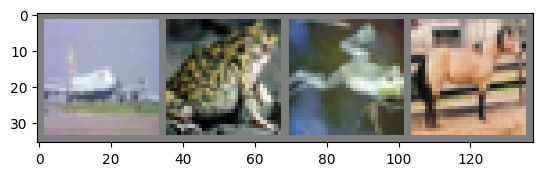

plane frog  frog  horse


In [44]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(trainloader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))
# print labels
print(' '.join(f'{classes[labels[j]]:5s}' for j in range(batch_size)))

In [45]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [46]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(net.parameters(), lr=0.001, momentum=0.9)

In [47]:
for epoch in range(2):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = net(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 2000 == 1999:    # print every 2000 mini-batches
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 2000:.3f}')
            running_loss = 0.0

print('Finished Training')

[1,  2000] loss: 2.198
[1,  4000] loss: 1.889
[1,  6000] loss: 1.663
[1,  8000] loss: 1.583
[1, 10000] loss: 1.498
[1, 12000] loss: 1.456
[2,  2000] loss: 1.376
[2,  4000] loss: 1.339
[2,  6000] loss: 1.328
[2,  8000] loss: 1.323
[2, 10000] loss: 1.268
[2, 12000] loss: 1.259
Finished Training


In [48]:
PATH = './cifar_net.pth'
torch.save(net.state_dict(), PATH)

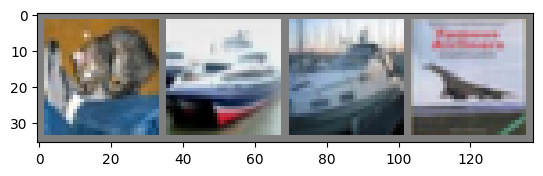

GroundTruth:  cat   ship  ship  plane


In [49]:
dataiter = iter(testloader)
images, labels = next(dataiter)

# print images
imshow(torchvision.utils.make_grid(images))
print('GroundTruth: ', ' '.join(f'{classes[labels[j]]:5s}' for j in range(4)))

In [50]:
net = Net()
net.load_state_dict(torch.load(PATH, weights_only=True))

<All keys matched successfully>

In [51]:
outputs = net(images)

In [52]:
_, predicted = torch.max(outputs, 1)

print('Predicted: ', ' '.join(f'{classes[predicted[j]]:5s}'
                              for j in range(4)))

Predicted:  bird  ship  car   plane


In [53]:
correct = 0
total = 0
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        outputs = net(images)
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f'Accuracy of the network on the 10000 test images: {100 * correct // total} %')

Accuracy of the network on the 10000 test images: 55 %


In [54]:
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in testloader:
        images, labels = data
        outputs = net(images)
        _, predictions = torch.max(outputs, 1)
        # collecting the correct predictions for each class!!!
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label]] += 1
            total_pred[classes[label]] += 1


for classname, correct_count in correct_pred.items():
    accuracy = 100 * float(correct_count) / total_pred[classname]
    print(f'Accuracy for class: {classname}    | is {accuracy:.1f} %')

Accuracy for class: plane    | is 67.2 %
Accuracy for class: car    | is 73.1 %
Accuracy for class: bird    | is 64.1 %
Accuracy for class: cat    | is 29.2 %
Accuracy for class: deer    | is 37.5 %
Accuracy for class: dog    | is 45.7 %
Accuracy for class: frog    | is 66.6 %
Accuracy for class: horse    | is 46.1 %
Accuracy for class: ship    | is 66.1 %
Accuracy for class: truck    | is 63.2 %


In [55]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

# Assuming that we are on a CUDA machine, this should print a CUDA device:

print(device)

cpu


In [56]:
def evaluate_accuracy(model, loader):
    correct = 0
    total = 0

    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    return 100 * correct / total


In [57]:
def train_model(model, optimizer, criterion, epochs=5):

    for epoch in range(epochs):
        running_loss = 0.0

        for images, labels in trainloader:

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {running_loss}")

    train_acc = evaluate_accuracy(model, trainloader)
    test_acc = evaluate_accuracy(model, testloader)

    return train_acc, test_acc


# Hyperparameter1

In [58]:
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

class Net1(nn.Module):
    def __init__(self):
        super(Net1, self).__init__()
        # Changing the Convo here!!!!
        self.conv1 = nn.Conv2d(3, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(6 * 14 * 14, 120)
        self.fc2 = nn.Linear(120, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(-1, 6 * 14 * 14)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model1 = Net1()
optimizer1 = optim.SGD(model1.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

train_acc1, test_acc1 = train_model(model1, optimizer1, criterion)


Epoch 1, Loss: 20036.989051386714
Epoch 2, Loss: 16788.559591703117
Epoch 3, Loss: 15179.637409612536
Epoch 4, Loss: 13899.692519664764
Epoch 5, Loss: 12837.11417759955


# Hyperparameter2

In [59]:
class Net2(nn.Module):
    def __init__(self):
        super(Net2, self).__init__()
        # Changing the Convo here!!!!
        self.conv1 = nn.Conv2d(3, 16, 5)

        # Adding 2nd convo!!
        self.conv2 = nn.Conv2d(16, 32, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 5 * 5, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(-1, 32 * 5 * 5)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model2 = Net2()
optimizer2 = optim.Adam(model2.parameters(), lr=0.001)

train_acc2, test_acc2 = train_model(model2, optimizer2, criterion)


Epoch 1, Loss: 19694.091880962253
Epoch 2, Loss: 16270.42650661245
Epoch 3, Loss: 14652.230145793408
Epoch 4, Loss: 13552.837060472928
Epoch 5, Loss: 12702.777262654272


# Hyperparameter3

In [60]:
class Net3(nn.Module):
    def __init__(self):
        super(Net3, self).__init__()

        # Changing convo metric again.
        self.conv1 = nn.Conv2d(3, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(32 * 6 * 6, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(torch.tanh(self.conv1(x)))
        x = self.pool(torch.tanh(self.conv2(x)))
        x = x.view(-1, 32 * 6 * 6)
        x = torch.tanh(self.fc1(x))
        x = self.fc2(x)
        return x

model3 = Net3()
optimizer3 = optim.SGD(model3.parameters(), lr=0.1)

train_acc3, test_acc3 = train_model(model3, optimizer3, criterion)


Epoch 1, Loss: 30154.175081966445
Epoch 2, Loss: 31992.868666041642
Epoch 3, Loss: 31892.508376315236
Epoch 4, Loss: 31249.876266200095
Epoch 5, Loss: 31685.051760196686


# Optuna

In [73]:
!pip install optuna


In [74]:
import torch.nn as nn
import torch.nn.functional as F

class CNNModel(nn.Module):
    def __init__(self, n_hidden):
        super(CNNModel, self).__init__()

        self.conv1 = nn.Conv2d(3, 16, 3)
        self.conv2 = nn.Conv2d(16, 32, 3)
        self.pool = nn.MaxPool2d(2, 2)

        self.fc1 = nn.Linear(32 * 6 * 6, n_hidden)
        self.fc2 = nn.Linear(n_hidden, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


In [75]:
import optuna
import torch.nn as nn
import torch.optim as optim


def objective(trial):

    # Hyperparameters to tune
    n_hidden = trial.suggest_int("n_hidden", 64, 256)
    lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)
    optimizer_name = trial.suggest_categorical("optimizer", ["Adam", "SGD"])

    # Build model
    model = CNNModel(n_hidden)  # assume you pass n_hidden to fc1

    criterion = nn.CrossEntropyLoss()

    if optimizer_name == "Adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(model.parameters(), lr=lr)

    # Train model (few epochs for tuning)
    train_model(model, optimizer, criterion, epochs=3)

    # Evaluate validation accuracy
    val_acc = evaluate_accuracy(model, testloader)

    return val_acc


In [ ]:
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=20)

print("Best Hyperparameters:", study.best_params)


[I 2026-03-01 02:56:36,688] A new study created in memory with name: no-name-66f1505f-58a6-4d29-a509-3ae5de0eed57
/tmp/ipython-input-242/3632001164.py:10: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  lr = trial.suggest_loguniform("lr", 1e-4, 1e-1)


Epoch 1, Loss: 25495.27769845724
Epoch 2, Loss: 20304.963254660368
Epoch 3, Loss: 17845.692801967263


[I 2026-03-01 03:04:24,687] Trial 0 finished with value: 51.26 and parameters: {'n_hidden': 213, 'lr': 0.0010959304027558054, 'optimizer': 'SGD'}. Best is trial 0 with value: 51.26.


Epoch 1, Loss: 28345.76953148842
Epoch 2, Loss: 25760.257548749447
Epoch 3, Loss: 23584.57794892788


[I 2026-03-01 03:11:43,677] Trial 1 finished with value: 34.94 and parameters: {'n_hidden': 172, 'lr': 0.00032466773813073834, 'optimizer': 'SGD'}. Best is trial 0 with value: 51.26.


Epoch 1, Loss: 28717.303908348083
Epoch 2, Loss: 28443.169899225235
Epoch 3, Loss: 27467.43497824669


[I 2026-03-01 03:19:00,830] Trial 2 finished with value: 25.63 and parameters: {'n_hidden': 68, 'lr': 0.00014015986165826327, 'optimizer': 'SGD'}. Best is trial 0 with value: 51.26.
